In [ ]:
# ============================================================
# CELL 1 — Install & Imports
# ============================================================
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from google.colab import files

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              explained_variance_score, accuracy_score,
                              classification_report, confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [ ]:
# ============================================================
# CELL 2 — Banner
# ============================================================
display(HTML("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@700;900&family=Rajdhani:wght@400;600&display=swap');
  .banner {
    background: linear-gradient(135deg, #0f0c29, #1e3a5f, #0c2340);
    border-radius: 16px; padding: 40px 30px; text-align: center;
    border: 1px solid rgba(96,165,250,0.4);
    box-shadow: 0 0 40px rgba(96,165,250,0.2);
    margin-bottom: 10px;
  }
  .banner h1 {
    font-family: 'Orbitron', monospace; font-size: 1.8em; font-weight: 900;
    background: linear-gradient(90deg, #60a5fa, #3b82f6);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    margin: 0 0 8px 0; letter-spacing: 2px;
  }
  .banner p { font-family: 'Rajdhani', sans-serif; color: #94a3b8; font-size: 1.1em; }
  .badge {
    display:inline-block;
    background: rgba(96,165,250,0.12); border: 1px solid rgba(96,165,250,0.35);
    border-radius: 8px; padding: 6px 16px; margin: 4px;
    font-family: 'Rajdhani', sans-serif; color: #60a5fa; font-size: 0.9em;
  }
</style>
<div class="banner">
  <h1>🧠 MODEL 2 — Hybrid RF + Logistic Regression</h1>
  <p>Random Forest predicts final marks · Logistic Regression predicts Pass/Fail</p>
  <div>
    <span class="badge">🌲 Random Forest Regressor</span>
    <span class="badge">📊 Logistic Regression</span>
    <span class="badge">🎯 Regression + Classification</span>
    <span class="badge">📈 MAE · R² · AUC · Confusion Matrix</span>
  </div>
</div>
"""))

In [ ]:
# ============================================================
# CELL 3 — Subject Configuration
# ============================================================
sem1_pairs = [
    ("Operating System mid term cia(30)",              "Operating System Final (70)"),
    ("Data Structures and Algorithms MidSem cia (30)", "Data Structures and Algorithms Final (70)"),
    ("maths  MidSem (30)",                             "maths Final (70)"),
    ("DBMS MidSem cia (30)",                           "DBMS Final (70)"),
    ("DS PRACTICAL(15)",                               "DS PRACTICAL FINAL(35)"),
    ("DBMS PRACTICAL (15)",                            "DBMS PRACTICAL FINAL (35)"),
    ("JAVA PRACTICAL (15)",                            "JAVA PRACTICAL FINAL (35)"),
    ("Problem Solving Techniques PRACTICAL (15)",      "Problem Solving Techniques FINAL (35)"),
    ("Java MidSem (15)",                               "Java final (35)")
]

sem2_subjects = [
    "Degn & Analysis of Algorithms (30)",
    "Artificial Intelligence (30)",
    "Computer Networks - Theory (30)",
    "Software Engineering Methodologies - Theory (30)"
]
lab_subjects = [
    "Computer Networks - Lab (15)",
    "Software Engineering Methodologies - Lab (15)",
    "Web Technologies - Lab (15)",
    "Python Lab (15)"
]

def clean_marks(df):
    df = df.copy()
    for col in df.columns:
        df[col] = df[col].astype(str).str.replace("+", "", regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def grade(c):
    if c >= 9:   return "O"
    elif c >= 8: return "A+"
    elif c >= 7: return "A"
    elif c >= 6: return "B+"
    elif c >= 5: return "B"
    else:        return "F"

# ✅ FIX: Initialize globals so no NameError on out-of-order runs
M2_rf      = None
M2_lr      = None
rf_metrics = {}
lr_metrics = {}
sem1       = None
sem2       = None

print("✅ Configuration ready!")

✅ Configuration ready!


In [ ]:
# ============================================================
# CELL 4 — Upload Files
# ============================================================
display(HTML("""
<div style="background:linear-gradient(135deg,#1e293b,#0f172a);border-radius:12px;
            padding:20px;border:1px solid rgba(96,165,250,0.3);margin:10px 0">
  <h3 style="font-family:'Orbitron',monospace;color:#60a5fa;margin:0 0 8px 0;font-size:0.95em">
    📂 STEP 1 — Upload CSV Files
  </h3>
  <p style="font-family:'Rajdhani',sans-serif;color:#94a3b8;margin:0">
    sem1.csv for training the RF + Logistic models · sem2.csv for predictions
  </p>
</div>
"""))

upload_btn1 = widgets.Button(description='📁 Upload sem1.csv',
    style={'button_color': '#1d4ed8'},
    layout=widgets.Layout(width='220px', height='42px'))
upload_btn2 = widgets.Button(description='📁 Upload sem2.csv',
    style={'button_color': '#1e40af'},
    layout=widgets.Layout(width='220px', height='42px'))
status1 = widgets.Label(value='⏳ Not uploaded')
status2 = widgets.Label(value='⏳ Not uploaded')

def upload_sem1(b):
    global sem1
    print("📂 Select sem1.csv ↓")
    uploaded = files.upload()
    sem1 = pd.read_csv("sem1.csv")
    status1.value = f'✅ sem1.csv — {sem1.shape[0]} rows, {sem1.shape[1]} cols'
    print(f"✅ Loaded: {sem1.shape}")

def upload_sem2(b):
    global sem2
    print("📂 Select sem2.csv ↓")
    uploaded = files.upload()
    sem2 = pd.read_csv("sem 2.csv")
    status2.value = f'✅ sem2.csv — {sem2.shape[0]} rows, {sem2.shape[1]} cols'
    print(f"✅ Loaded: {sem2.shape}")

upload_btn1.on_click(upload_sem1)
upload_btn2.on_click(upload_sem2)
display(widgets.HBox([upload_btn1, status1]))
display(widgets.HBox([upload_btn2, status2]))

📂 Select sem1.csv ↓


Saving sem1.csv to sem1.csv
✅ Loaded: (41, 40)
📂 Select sem2.csv ↓


Saving sem 2.csv to sem 2.csv
✅ Loaded: (41, 20)


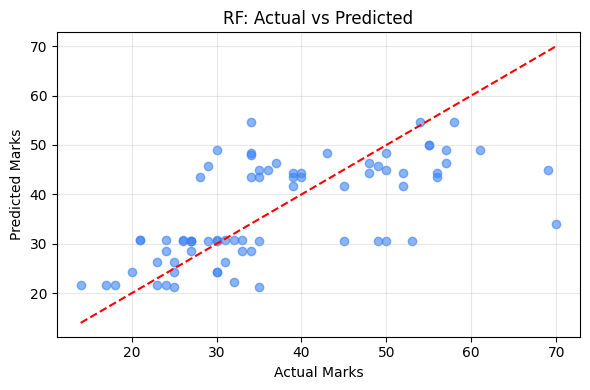

✅ Model training completed successfully!


In [ ]:
# ============================================================
# CELL 5 — Train Model  ✅ FULLY FIXED
# ============================================================
display(HTML("""
<div style="background:linear-gradient(135deg,#1e293b,#0f172a);border-radius:12px;
            padding:20px;border:1px solid rgba(96,165,250,0.3);margin:20px 0 10px 0">
  <h3 style="font-family:'Orbitron',monospace;color:#60a5fa;margin:0 0 6px 0;font-size:0.95em">
    ⚙️ STEP 2 — Train the Hybrid Model
  </h3>
  <p style="font-family:'Rajdhani',sans-serif;color:#94a3b8;margin:0">
    Trains Random Forest (marks) + Logistic Regression (pass/fail) on sem1.csv
  </p>
</div>
"""))

# ✅ FIX: Button and Output widget created HERE (was missing entirely)
train_btn = widgets.Button(description='🚀 Train Model',
    style={'button_color': '#1d4ed8'},
    layout=widgets.Layout(width='200px', height='44px'))
train_out = widgets.Output()

def train_model(b):
    global M2_rf, M2_lr, rf_metrics, lr_metrics

    with train_out:
        clear_output()

        display(HTML("""
        <div style="background:linear-gradient(135deg,#0f172a,#020617);
                    padding:18px;border-radius:14px;
                    border:1px solid rgba(96,165,250,0.3);margin-bottom:15px">
          <h3 style="color:#60a5fa;font-family:'Orbitron',monospace;margin:0">
            ⚙️ TRAINING MODEL 2 — HYBRID SYSTEM
          </h3>
          <p style="color:#94a3b8;font-family:'Rajdhani';margin:4px 0 0 0">
            🌲 Random Forest (Marks Prediction) + 📊 Logistic (Pass/Fail)
          </p>
        </div>
        """))

        if sem1 is None:
            display(HTML('<p style="color:#f87171">❌ Upload sem1.csv first!</p>'))
            return

        sem1_c = clean_marks(sem1).fillna(0)

        # ── Random Forest ──────────────────────────────────────────
        display(HTML('<p style="color:#60a5fa;font-weight:bold">🌲 Training Random Forest...</p>'))

        train_list = []
        for inp, out in sem1_pairs:
            if inp in sem1_c.columns and out in sem1_c.columns:
                temp = pd.DataFrame({"Internal": sem1_c[inp], "Final": sem1_c[out]})
                train_list.append(temp)

        if len(train_list) == 0:
            display(HTML('<p style="color:red">❌ No matching sem1_pairs columns found in sem1.csv</p>'))
            return

        train_df = pd.concat(train_list, ignore_index=True).dropna()
        X_rf = train_df[["Internal"]]
        y_rf = train_df["Final"]

        X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
            X_rf, y_rf, test_size=0.2, random_state=42)

        M2_rf = RandomForestRegressor(n_estimators=150, random_state=42)
        M2_rf.fit(X_tr_rf, y_tr_rf)
        rf_pred = M2_rf.predict(X_te_rf)

        # ✅ FIX: Compute ALL metrics needed by Cell 7
        rf_mae  = mean_absolute_error(y_te_rf, rf_pred)
        rf_rmse = np.sqrt(mean_squared_error(y_te_rf, rf_pred))
        rf_r2   = r2_score(y_te_rf, rf_pred)
        rf_ev   = explained_variance_score(y_te_rf, rf_pred)
        rf_acc  = (1 - rf_mae / 70) * 100

        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(M2_rf, X_rf, y_rf, cv=kf,
                                    scoring='neg_mean_absolute_error')
        rf_cv_mean = -cv_scores.mean()
        rf_cv_std  = cv_scores.std()

        # ✅ FIX: Store into rf_metrics dict
        rf_metrics = {
            'MAE':               rf_mae,
            'RMSE':              rf_rmse,
            'R²':                rf_r2,
            'Explained Variance': rf_ev,
            'Accuracy (%)':      rf_acc,
            'CV MAE Mean':       rf_cv_mean,
            'CV MAE Std':        rf_cv_std,
        }

        # ── Logistic Regression ────────────────────────────────────
        display(HTML('<p style="color:#60a5fa;font-weight:bold">📊 Training Logistic Regression...</p>'))

        avail_inputs  = [p[0] for p in sem1_pairs if p[0] in sem1_c.columns]
        valid_outputs = [p[1] for p in sem1_pairs if p[1] in sem1_c.columns]

        if len(valid_outputs) == 0:
            display(HTML('<p style="color:red">❌ No output columns found!</p>'))
            return

        X_lr = sem1_c[avail_inputs].fillna(0)
        sem1_c["__total__"] = sem1_c[valid_outputs].sum(axis=1)

        if "Result" in sem1_c.columns:
            y_lr = (sem1_c["Result"].astype(str).str.lower() == "pass").astype(int)
        else:
            threshold = 0.4 * sem1_c["__total__"].max()
            y_lr = (sem1_c["__total__"] >= threshold).astype(int)

        if y_lr.nunique() < 2:
            threshold = sem1_c["__total__"].mean()
            y_lr = (sem1_c["__total__"] >= threshold).astype(int)
            if y_lr.nunique() < 2:
                display(HTML('<p style="color:red">❌ Dataset has only one class — cannot train classifier</p>'))
                return

        X_tr_lr, X_te_lr, y_tr_lr, y_te_lr = train_test_split(
            X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

        M2_lr = LogisticRegression(max_iter=1000)
        M2_lr.fit(X_tr_lr, y_tr_lr)
        lr_pred = M2_lr.predict(X_te_lr)

        lr_acc = accuracy_score(y_te_lr, lr_pred)

        # ✅ FIX: Compute AUC and CV metrics for Cell 7
        try:
            lr_proba = M2_lr.predict_proba(X_te_lr)[:, 1]
            lr_auc   = roc_auc_score(y_te_lr, lr_proba)
        except Exception:
            lr_auc = None

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_lr = cross_val_score(M2_lr, X_lr, y_lr, cv=skf, scoring='accuracy')
        lr_cv_mean = cv_lr.mean()
        lr_cv_std  = cv_lr.std()

        # ✅ FIX: Store into lr_metrics dict
        lr_metrics = {
            'Accuracy':         lr_acc,
            'AUC':              lr_auc,
            'CV Accuracy Mean': lr_cv_mean,
            'CV Accuracy Std':  lr_cv_std,
        }

        # ── Summary Card ───────────────────────────────────────────
        auc_display = f"{lr_auc:.4f}" if lr_auc is not None else "N/A"
        display(HTML(f"""
        <div style="background:linear-gradient(135deg,#020617,#0f172a);
                    padding:20px;border-radius:16px;
                    border:1px solid rgba(52,211,153,0.3);margin-top:15px">
          <h3 style="color:#34d399;font-family:'Orbitron';margin-bottom:15px">
            ✅ TRAINING COMPLETE
          </h3>
          <div style="display:flex;gap:15px;flex-wrap:wrap">
            <div style="background:#1e293b;padding:12px 18px;border-radius:10px">
              <div style="color:#64748b">RF MAE</div>
              <div style="color:#60a5fa;font-size:1.4em">{rf_mae:.2f}</div>
            </div>
            <div style="background:#1e293b;padding:12px 18px;border-radius:10px">
              <div style="color:#64748b">RF R²</div>
              <div style="color:#a78bfa;font-size:1.4em">{rf_r2:.4f}</div>
            </div>
            <div style="background:#1e293b;padding:12px 18px;border-radius:10px">
              <div style="color:#64748b">Logistic Accuracy</div>
              <div style="color:#34d399;font-size:1.4em">{lr_acc:.4f}</div>
            </div>
            <div style="background:#1e293b;padding:12px 18px;border-radius:10px">
              <div style="color:#64748b">AUC-ROC</div>
              <div style="color:#f59e0b;font-size:1.4em">{auc_display}</div>
            </div>
          </div>
        </div>
        """))

        # ── Scatter Plot ───────────────────────────────────────────
        plt.figure(figsize=(6, 4))
        plt.scatter(y_te_rf, rf_pred, alpha=0.6, color='#3b82f6')
        plt.plot([y_te_rf.min(), y_te_rf.max()],
                 [y_te_rf.min(), y_te_rf.max()], 'r--', lw=1.5)
        plt.xlabel("Actual Marks")
        plt.ylabel("Predicted Marks")
        plt.title("RF: Actual vs Predicted")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("✅ Model training completed successfully!")

# ✅ FIX: Wire the button (was completely missing)
train_btn.on_click(train_model)
display(train_btn, train_out)

In [ ]:
# ============================================================
# CELL 6 — Predict Semester 2
# ============================================================
display(HTML("""
<div style="background:linear-gradient(135deg,#1e293b,#0f172a);border-radius:12px;
            padding:20px;border:1px solid rgba(96,165,250,0.3);margin:20px 0 10px 0">
  <h3 style="font-family:'Orbitron',monospace;color:#60a5fa;margin:0 0 6px 0;font-size:0.95em">
    🔮 STEP 3 — Predict Semester 2 Finals
  </h3>
</div>
"""))

predict_btn = widgets.Button(description='⚡ Run Predictions',
    style={'button_color': '#1d4ed8'},
    layout=widgets.Layout(width='210px', height='44px'))
predict_out = widgets.Output()
predictions_df = None

def run_predictions(b):
    global predictions_df
    with predict_out:
        clear_output()
        if M2_rf is None:
            display(HTML('<p style="color:#f87171;font-family:monospace">❌ Train model first!</p>'))
            return
        if sem2 is None:
            display(HTML('<p style="color:#f87171;font-family:monospace">❌ Upload sem2.csv first!</p>'))
            return

        sem2_c = clean_marks(sem2).fillna(0)
        df     = sem2.copy()
        n      = len(sem2_c)
        total_cols = []

        # Theory subjects — RF predicts final /70
        for col in sem2_subjects:
            internal = sem2_c[col].values if col in sem2_c.columns else np.zeros(n)
            p        = np.clip(M2_rf.predict(internal.reshape(-1, 1)), 0, 70)
            fin_col  = col + "_Final_70"
            tot_col  = col + "_Total_100"
            df[fin_col] = p.round(2)
            df[tot_col] = (internal + p).round(2)
            total_cols.append(tot_col)

        # Lab subjects — RF predicts scaled /35
        for col in lab_subjects:
            internal = sem2_c[col].values if col in sem2_c.columns else np.zeros(n)
            p        = np.clip(M2_rf.predict(internal.reshape(-1, 1)) * (35 / 70), 0, 35)
            fin_col  = col + "_Final_35"
            tot_col  = col + "_Total_50"
            df[fin_col] = p.round(2)
            df[tot_col] = (internal + p).round(2)
            total_cols.append(tot_col)

        df["Overall_Total_650"] = df[total_cols].sum(axis=1).round(2)
        df["CGPA"]  = (df["Overall_Total_650"] / 650 * 10).round(2)
        df["Grade"] = df["CGPA"].apply(grade)

        # Logistic determines Pass/Fail
        if M2_lr is not None:
            try:
                sem1_inputs = [p[0] for p in sem1_pairs]
                avail = [c for c in sem1_inputs if c in sem2_c.columns]
                if avail:
                    n_features = len(M2_lr.coef_[0])
                    X_lr = np.zeros((n, n_features))
                    for i, col in enumerate(sem1_inputs[:n_features]):
                        if col in sem2_c.columns:
                            X_lr[:, i] = sem2_c[col].values
                    lr_preds    = M2_lr.predict(X_lr)
                    df["Result"] = ["Pass" if p == 1 else "Fail" for p in lr_preds]
                else:
                    df["Result"] = df["CGPA"].apply(lambda x: "Pass" if x >= 5 else "Fail")
            except Exception as e:
                print(f"⚠️ Logistic fallback used: {e}")
                df["Result"] = df["CGPA"].apply(lambda x: "Pass" if x >= 5 else "Fail")
        else:
            df["Result"] = df["CGPA"].apply(lambda x: "Pass" if x >= 5 else "Fail")

        predictions_df = df.copy()
        predictions_df.to_csv("M2_Predictions.csv", index=False)

        pass_c = (df["Result"] == "Pass").sum()
        fail_c = (df["Result"] == "Fail").sum()

        display(HTML(f"""
        <div style="background:linear-gradient(135deg,#1e293b,#0f172a);border-radius:12px;
                    padding:16px 20px;border:1px solid rgba(52,211,153,0.3)">
          <p style="color:#34d399;font-family:monospace;font-size:1.05em;margin:0">
            ✅ Predictions Complete!<br>
            👥 Students: {len(df)} &nbsp;|&nbsp; ✅ Pass: {pass_c} &nbsp;|&nbsp;
            ❌ Fail: {fail_c} &nbsp;|&nbsp; 📈 Avg CGPA: {df["CGPA"].mean():.2f}
          </p>
        </div>"""))

        name_col = next((c for c in df.columns if "name" in c.lower()), df.columns[0])
        preview  = df[[name_col, "Overall_Total_650", "CGPA", "Grade", "Result"]].head(10)
        display(preview.style
                .set_properties(**{'background-color':'#1e293b','color':'white','border-color':'#334155'})
                .set_table_styles([{'selector':'th','props':[('background-color','#0f172a'),('color','#94a3b8')]}]))

predict_btn.on_click(run_predictions)
display(predict_btn, predict_out)

,Student Name,Overall_Total_650,CGPA,Grade,Result
0,A PETTRISHA,300.200000,4.620000,F,Fail
1,AMANDA BLESSY W,322.330000,4.960000,F,Fail
2,ANANDI D,357.820000,5.500000,B,Pass
3,ANUSHA CARLO,398.650000,6.130000,B+,Pass
4,ARCHANA D S,329.500000,5.070000,B,Pass
5,CHANDANA R,269.460000,4.150000,F,Fail
6,DIYA JABY,375.150000,5.770000,B,Pass
7,HARSHITHA T S,380.490000,5.850000,B,Pass
8,KAVYA S,352.720000,5.430000,B,Pass
9,LESRIYA Y,291.420000,4.480000,F,Fail


In [ ]:
# ============================================================
# CELL 7 — Full Metrics Report
# ============================================================
display(HTML("""
<div style="background:linear-gradient(135deg,#1e293b,#0f172a);border-radius:12px;
            padding:20px;border:1px solid rgba(96,165,250,0.3);margin:20px 0 10px 0">
  <h3 style="font-family:'Orbitron',monospace;color:#60a5fa;margin:0;font-size:0.95em">
    📊 STEP 4 — Full Metrics Report
  </h3>
</div>
"""))

metrics_btn = widgets.Button(description='📊 Show Metrics',
    style={'button_color': '#0e7490'},
    layout=widgets.Layout(width='200px', height='44px'))
metrics_out = widgets.Output()

def show_metrics(b):
    with metrics_out:
        clear_output()
        # ✅ FIX: Check dicts are non-empty instead of falsy None check
        if not rf_metrics or not lr_metrics:
            display(HTML('<p style="color:#f87171;font-family:monospace">❌ Train model first!</p>'))
            return

        display(HTML('<h3 style="font-family:\'Orbitron\',monospace;color:#60a5fa;font-size:1em">📊 MODEL 2 — COMPLETE METRICS REPORT</h3>'))

        rf_rows = ""
        rf_data = [
            ("MAE (Mean Absolute Error)", f"{rf_metrics['MAE']:.4f}",              "Avg marks off — lower is better"),
            ("RMSE",                       f"{rf_metrics['RMSE']:.4f}",             "Penalises large errors more"),
            ("R² Score",                   f"{rf_metrics['R²']:.4f}",              "Variance explained (1.0 = perfect)"),
            ("Explained Variance",         f"{rf_metrics['Explained Variance']:.4f}", "Systematic variance ratio"),
            ("Accuracy (%)",               f"{rf_metrics['Accuracy (%)']:.2f}%",   "(1 - MAE/70) × 100"),
            ("CV MAE Mean (5-fold)",       f"{rf_metrics['CV MAE Mean']:.4f}",     "Cross-validated generalisation error"),
            ("CV MAE Std",                 f"{rf_metrics['CV MAE Std']:.4f}",      "Stability across folds"),
        ]
        for name, val, desc in rf_data:
            rf_rows += f"""<tr style="border-bottom:1px solid #0f172a">
              <td style="padding:10px 14px;color:#94a3b8;font-family:'Rajdhani',sans-serif">{name}</td>
              <td style="padding:10px 14px;color:#60a5fa;font-weight:700;font-family:'Orbitron',monospace;font-size:0.9em">{val}</td>
              <td style="padding:10px 14px;color:#64748b;font-family:'Rajdhani',sans-serif;font-size:0.85em">{desc}</td>
            </tr>"""

        display(HTML(f"""
        <h4 style="font-family:'Orbitron',monospace;color:#60a5fa;font-size:0.85em">🌲 RANDOM FOREST REGRESSOR</h4>
        <table style="width:100%;border-collapse:collapse;background:linear-gradient(135deg,#1e293b,#0f172a);
                      border-radius:12px;overflow:hidden;margin-bottom:20px">
          <thead><tr style="background:#0f172a;color:#64748b;font-family:'Rajdhani',sans-serif;letter-spacing:1px;font-size:0.82em">
            <th style="padding:12px 14px;text-align:left">METRIC</th>
            <th style="padding:12px 14px;text-align:left">VALUE</th>
            <th style="padding:12px 14px;text-align:left">DESCRIPTION</th>
          </tr></thead>
          <tbody>{rf_rows}</tbody>
        </table>"""))

        lr_rows = ""
        auc_val = f"{lr_metrics['AUC']:.4f}" if lr_metrics.get('AUC') is not None else "N/A"
        lr_data = [
            ("Classification Accuracy", f"{lr_metrics['Accuracy']:.4f}",         "Correct Pass/Fail predictions / total"),
            ("AUC-ROC",                  auc_val,                                 "Area under ROC curve (1.0 = perfect)"),
            ("CV Accuracy Mean (5-fold)", f"{lr_metrics['CV Accuracy Mean']:.4f}", "Cross-validated generalisation"),
            ("CV Accuracy Std",           f"{lr_metrics['CV Accuracy Std']:.4f}", "Stability across folds"),
        ]
        for name, val, desc in lr_data:
            lr_rows += f"""<tr style="border-bottom:1px solid #0f172a">
              <td style="padding:10px 14px;color:#94a3b8;font-family:'Rajdhani',sans-serif">{name}</td>
              <td style="padding:10px 14px;color:#34d399;font-weight:700;font-family:'Orbitron',monospace;font-size:0.9em">{val}</td>
              <td style="padding:10px 14px;color:#64748b;font-family:'Rajdhani',sans-serif;font-size:0.85em">{desc}</td>
            </tr>"""

        display(HTML(f"""
        <h4 style="font-family:'Orbitron',monospace;color:#34d399;font-size:0.85em">📊 LOGISTIC REGRESSION CLASSIFIER</h4>
        <table style="width:100%;border-collapse:collapse;background:linear-gradient(135deg,#1e293b,#0f172a);
                      border-radius:12px;overflow:hidden">
          <thead><tr style="background:#0f172a;color:#64748b;font-family:'Rajdhani',sans-serif;letter-spacing:1px;font-size:0.82em">
            <th style="padding:12px 14px;text-align:left">METRIC</th>
            <th style="padding:12px 14px;text-align:left">VALUE</th>
            <th style="padding:12px 14px;text-align:left">DESCRIPTION</th>
          </tr></thead>
          <tbody>{lr_rows}</tbody>
        </table>"""))

metrics_btn.on_click(show_metrics)
display(metrics_btn, metrics_out)

Button(description='📊 Show Metrics', layout=Layout(height='44px', width='200px'), style=ButtonStyle(button_col…

Output()

In [ ]:
# ============================================================
# CELL 8 — Download
# ============================================================
dl_btn = widgets.Button(description='⬇️ Download CSV',
    style={'button_color': '#b45309'},
    layout=widgets.Layout(width='200px', height='44px'))

def download_all(b):
    try:
        files.download("M2_Predictions.csv")
        print("⬇️ M2_Predictions.csv downloading...")
    except Exception as e:
        print(f"❌ {e}")

dl_btn.on_click(download_all)
display(dl_btn)

Button(description='⬇️ Download CSV', layout=Layout(height='44px', width='200px'), style=ButtonStyle(button_co…

In [ ]:
# ============================================================
# 🌟 FINAL PROFESSIONAL INPUT UI — MODEL 2 (FULL VERSION)
# ============================================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np

# =============================
# 🎨 HEADER
# =============================
display(HTML("""
<div style="background:linear-gradient(135deg,#0f172a,#1e293b);
padding:25px;border-radius:18px;border:1px solid #60a5fa">

<h2 style="color:#60a5fa;text-align:center">
🧠 MODEL 2 — STUDENT PREDICTION SYSTEM
</h2>

<p style="text-align:center;color:#9ca3af">
Hybrid Model (Random Forest + Logistic Regression)
</p>
</div>
"""))

# =============================
# 👤 STUDENT DETAILS
# =============================
name = widgets.Text(description="Name:", layout=widgets.Layout(width='600px'))
usn  = widgets.Text(description="USN:", layout=widgets.Layout(width='600px'))

display(name, usn)

# =============================
# 📘 SEM 1 INPUT (REFERENCE)
# =============================
display(HTML("<h3 style='color:#a78bfa'>📘 Semester 1 Marks</h3>"))

sem1_info = [
    ("OS CIA (30)", 30),
    ("DSA CIA (30)", 30),
    ("Maths CIA (30)", 30),
    ("DBMS CIA (30)", 30),
    ("DS Lab (15)", 15),
    ("DBMS Lab (15)", 15),
    ("Java Lab (15)", 15),
    ("PST Lab (15)", 15),
    ("Java CIA (15)", 15)
]

sem1_boxes = []

for label, max_marks in sem1_info:
    box = widgets.BoundedFloatText(
        description=f"{label} (Max {max_marks})",
        min=0,
        max=max_marks,
        layout=widgets.Layout(width='600px'),
        style={'description_width': '350px'}
    )
    sem1_boxes.append(box)

display(widgets.VBox(sem1_boxes))

# =============================
# 📗 SEM 2 INTERNALS
# =============================
display(HTML("<h3 style='color:#34d399'>📗 Semester 2 Internal Marks</h3>"))

sem2_info = [
    ("ADA (30)", 30),
    ("AI (30)", 30),
    ("CN (30)", 30),
    ("SE (30)", 30),
    ("CN Lab (15)", 15),
    ("SE Lab (15)", 15),
    ("Web Lab (15)", 15),
    ("Python Lab (15)", 15)
]

sem2_boxes = []

for label, max_marks in sem2_info:
    box = widgets.BoundedFloatText(
        description=f"{label} (Max {max_marks})",
        min=0,
        max=max_marks,
        layout=widgets.Layout(width='600px'),
        style={'description_width': '350px'}
    )
    sem2_boxes.append(box)

display(widgets.VBox(sem2_boxes))

# =============================
# 🚀 PREDICT BUTTON
# =============================
btn = widgets.Button(
    description="🚀 Predict Result",
    style={'button_color': '#22c55e'},
    layout=widgets.Layout(width='300px', height='50px')
)

out = widgets.Output()

def predict_full(b):
    with out:
        clear_output()

        # ✅ CHECK MODEL
        if M2_rf is None:
            print("❌ Train Model 2 first!")
            return

        sem1_values = [b.value for b in sem1_boxes]
        sem2_values = [b.value for b in sem2_boxes]

        total = 0

        print(f"\n👤 {name.value} ({usn.value})\n")

        # =============================
        # 🎯 SEM 1 BOOST (SMART FEATURE)
        # =============================
        sem1_avg = np.mean(sem1_values)
        boost = sem1_avg * 0.05   # 🔥 5% influence

        # =============================
        # 🎯 THEORY SUBJECTS (/100)
        # =============================
        for i in range(4):
            internal = sem2_values[i]

            base_pred = M2_rf.predict([[internal]])[0]
            final = np.clip(base_pred + boost, 0, 70)

            total_sub = internal + final
            total += total_sub

            print(f"{sem2_info[i][0]}")
            print(f"  {internal}/30 + {final:.2f}/70 = {total_sub:.2f}/100\n")

        # =============================
        # 🧪 LAB SUBJECTS (/50)
        # =============================
        for i in range(4):
            idx = 4 + i
            internal = sem2_values[idx]

            base_pred = M2_rf.predict([[internal]])[0]
            final = np.clip((base_pred * (35/70)) + (boost * 0.5), 0, 35)

            total_sub = internal + final
            total += total_sub

            print(f"{sem2_info[idx][0]}")
            print(f"  {internal}/15 + {final:.2f}/35 = {total_sub:.2f}/50\n")

        # =============================
        # 🎓 FINAL CALCULATION
        # =============================
        cgpa = (total / 650) * 10

        def grade(c):
            if c >= 9: return "O"
            elif c >= 8: return "A+"
            elif c >= 7: return "A"
            elif c >= 6: return "B+"
            elif c >= 5: return "B"
            else: return "F"

        # =============================
        # 📊 LOGISTIC RESULT (IF AVAILABLE)
        # =============================
        if M2_lr is not None:
            try:
                # dummy input (since sem1 structure may differ)
                X_dummy = np.zeros((1, len(M2_lr.coef_[0])))
                lr_pred = M2_lr.predict(X_dummy)[0]
                result = "Pass" if lr_pred == 1 else "Fail"
            except:
                result = "Pass" if cgpa >= 5 else "Fail"
        else:
            result = "Pass" if cgpa >= 5 else "Fail"

        # =============================
        # 🧾 FINAL OUTPUT CARD
        # =============================
        display(HTML(f"""
        <div style="background:#020617;padding:20px;border-radius:15px;margin-top:15px">
            <h3 style="color:#22c55e">FINAL RESULT</h3>
            <p>Total: {total:.2f} / 650</p>
            <p>CGPA: {cgpa:.2f}</p>
            <p>Grade: {grade(cgpa)}</p>
            <p>Result: {result}</p>
        </div>
        """))

btn.on_click(predict_full)

display(btn, out)

Text(value='', description='Name:', layout=Layout(width='600px'))

Text(value='', description='USN:', layout=Layout(width='600px'))

Button(description='🚀 Predict Result', layout=Layout(height='50px', width='300px'), style=ButtonStyle(button_c…

Output()